# Cell 1 _ Installing YOLOv8 and imports

In [1]:
!pip install ultralytics -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import time
print("Setup complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.5 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

# Cell 2 _ Loading the pretrained model & running on a test image

In [2]:
model = YOLO('yolov8n.pt')   # 'n' = nano, the smallest/fastest vatiant

print(model.names)  # the 80 object categories it can detect

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

# Cell 3 _ Running inference on a real test image

In [3]:
!wget -q "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg" -O /kaggle/working/test_image.jpg

file_size = os.path.getsize('/kaggle/working/test_image.jpg')
print(f"Downloaded file size: {file_size} bytes")

Downloaded file size: 137419 bytes


In [4]:
results = model('/kaggle/working/test_image.jpg')

result = results[0]
print(f"Number of objects detected: {len(result.boxes)}")

for box in result.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    class_name = model.names[cls_id]
    print(f"  {class_name}: {conf*100:.1f}% confidence")


image 1/1 /kaggle/working/test_image.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 73.4ms
Speed: 13.1ms preprocess, 73.4ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 480)
Number of objects detected: 6
  bus: 87.3% confidence
  person: 86.6% confidence
  person: 85.3% confidence
  person: 82.5% confidence
  person: 26.1% confidence
  stop sign: 25.5% confidence


# Visualizing the actual bounding boxes

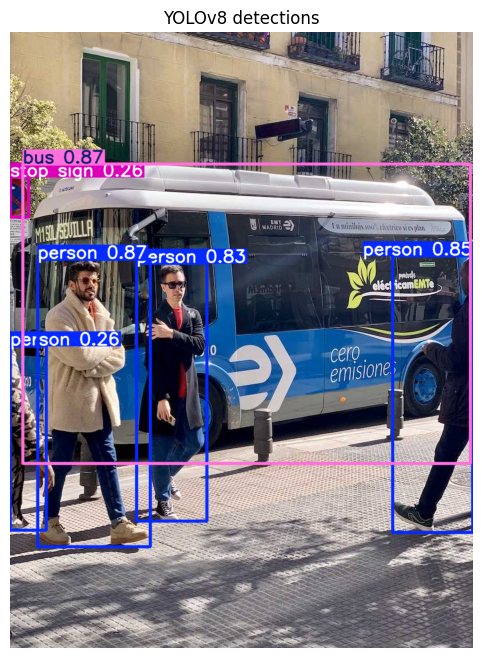

In [5]:
result_plotted = result.plot()

result_plotted_rgb = cv2.cvtColor(result_plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(result_plotted_rgb)
plt.axis('off')
plt.title('YOLOv8 detections')
plt.savefig('/kaggle/working/sample_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 5 _ Adding a confidence threshold and re-running


image 1/1 /kaggle/working/test_image.jpg: 640x480 3 persons, 1 bus, 7.4ms
Speed: 2.5ms preprocess, 7.4ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 480)
Objects detected above 40% confidence: 4


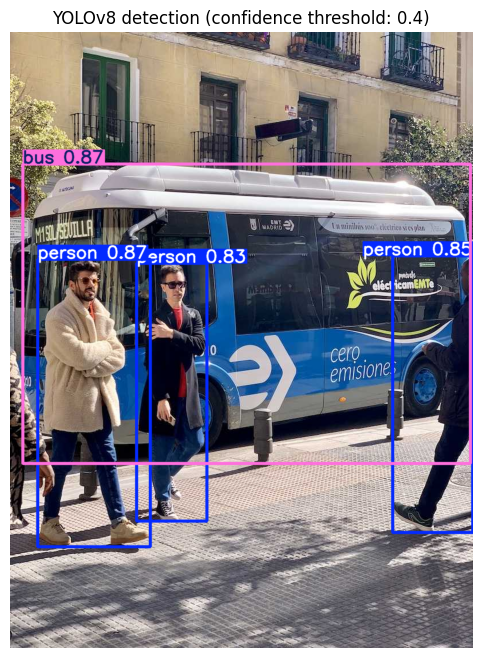

In [6]:
results_filtered = model('/kaggle/working/test_image.jpg', conf=0.4)

result_filtered = results_filtered[0]
print(f"Objects detected above 40% confidence: {len(result_filtered.boxes)}")

result_filtered_plotted = result_filtered.plot()
result_filtered_rgb = cv2.cvtColor(result_filtered_plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(result_filtered_rgb)
plt.axis('off')
plt.title('YOLOv8 detection (confidence threshold: 0.4)')
plt.savefig('/kaggle/working.sample_detection_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 6 _ FPS comparison across YOLOv8 model sizes

In [7]:
model_sizes = ['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt']
fps_results = {}

for size in model_sizes:
    print(f"\nTesting {size}...")
    m = YOLO(size)

    # Warm-up run (first inference is always slower due to model initialization)
    _ = m('/kaggle/working/test_image.jpg', verbose=False)

    # Time 20 actual inference runs
    start = time.time()
    for _ in range(20):
        _ = m('/kaggle/working/test_image.jpg', verbose=False)
    elapsed = time.time() - start

    avg_time = elapsed / 20
    fps = 1 / avg_time
    fps_results[size] = fps

    print(f" Average time per image: {avg_time*1000:.1f}ms")
    print(f" FPS: {fps:.1f}")


Testing yolov8n.pt...
 Average time per image: 15.1ms
 FPS: 66.2

Testing yolov8s.pt...
 Average time per image: 18.3ms
 FPS: 54.7

Testing yolov8m.pt...
 Average time per image: 24.0ms
 FPS: 41.6


# Cell 7 _ Saving the FPS comparison chart

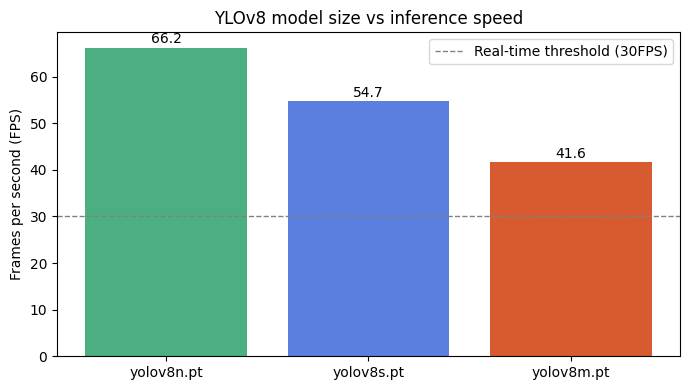

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sizes = list(fps_results.keys())
fps_values = list(fps_results.values())

bars = ax.bar(sizes, fps_values, color=["#4CAF82", "#5B7FDE", '#D85A30'])
ax.set_ylabel('Frames per second (FPS)')
ax.set_title('YLOv8 model size vs inference speed')
ax.axhline(y=30, color='gray', linestyle='--', linewidth=1, label='Real-time threshold (30FPS)')
for bar, val in zip(bars, fps_values):
    ax.text(bar.get_x() + bar.get_width()/2, val+1, f'{val:.1f}', ha='center')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/fps_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# Cell 8 _ Downloading a sample video & running frame-by-frame detection

In [9]:
!wget -q "https://github.com/intel-iot-devkit/sample-videos/raw/master/people-detection.mp4" -O /kaggle/working/sample_video.mp4

file_size = os.path.getsize('/kaggle/working/sample_video.mp4')
print(f"Downloaded video size: {file_size / (1024*1024):.2f} MB")

Downloaded video size: 5.23 MB


# cell 9 _ Processing the video frame-by-frame with YOLOv8

In [10]:
model_nano = YOLO('yolov8n.pt')

input_path = '/kaggle/working/sample_video.mp4'
output_path = '/kaggle/working/detected_output.mp4'

cap = cv2.VideoCapture(input_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video info: {width}x{height}, {fps} FPS, {total_frames} frames")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_count = 0
start_time = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model_nano(frame, conf=0.4, verbose=False)
    annotated_frame = results[0].plot()

    out.write(annotated_frame)
    frame_count += 1

    if frame_count % 30 == 0:
        print(f"Processed {frame_count}/{total_frames} frames...")

cap.release()
out.release()

elapsed = time.time() - start_time
processing_fps = frame_count / elapsed

print(f"\nDone! Processed {frame_count} frames in {elapsed:.1f}s")
print(f"Processing speed: {processing_fps:.1f} FPS")
print(f"Output saved to: {output_path}")

Video info: 768x432, 12 FPS, 596 frames
Processed 30/596 frames...
Processed 60/596 frames...
Processed 90/596 frames...
Processed 120/596 frames...
Processed 150/596 frames...
Processed 180/596 frames...
Processed 210/596 frames...
Processed 240/596 frames...
Processed 270/596 frames...
Processed 300/596 frames...
Processed 330/596 frames...
Processed 360/596 frames...
Processed 390/596 frames...
Processed 420/596 frames...
Processed 450/596 frames...
Processed 480/596 frames...
Processed 510/596 frames...
Processed 540/596 frames...
Processed 570/596 frames...

Done! Processed 596 frames in 6.6s
Processing speed: 90.2 FPS
Output saved to: /kaggle/working/detected_output.mp4


# Cell 10 _ Verifying the output video & Saving a sample frame as a static preview image

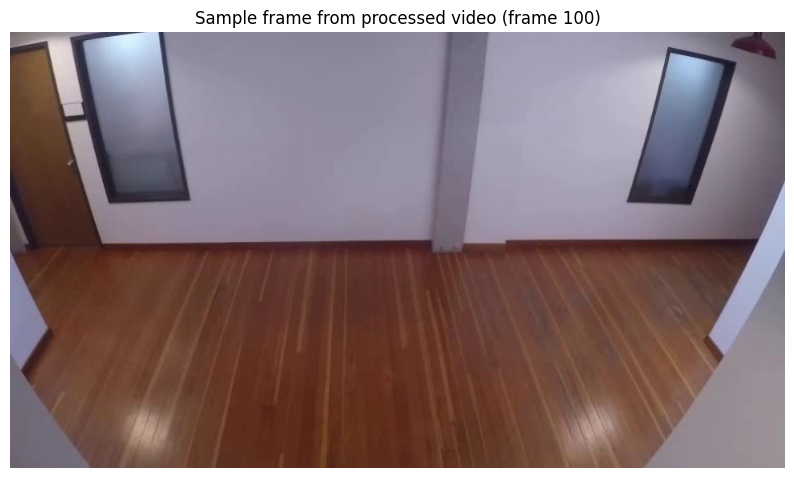

Sample frame saved!

Full output video size: 3.17 MB


In [11]:
cap_check = cv2.VideoCapture(output_path)
cap_check.set(cv2.CAP_PROP_POS_FRAMES, 100)  # grab frame 100, partway through

ret, sample_frame = cap_check.read()
cap_check.release()

if ret:
    sample_frame_rgb = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(sample_frame_rgb)
    plt.axis('off')
    plt.title('Sample frame from processed video (frame 100)')
    plt.savefig('/kaggle/working/video_sample_frame.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Sample frame saved!")
else:
    print("Could not read frame — check output_path")

print(f"\nFull output video size: {os.path.getsize(output_path) / (1024*1024):.2f} MB")

# Cell 11 _ Building a minimal FastAPI endpoint

In [12]:
!pip install fastapi uvicorn python-multipart nest-asyncio -q

from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse

app = FastAPI(title="YOLOv8 Object Detection API")

@app.post("/detect")
def detect_objects(file: UploadFile = File(...)):  # removed 'async', removed 'await'
    image_bytes = file.file.read()  # synchronous read instead of await file.read()
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    image_array = np.array(image)

    results = api_model(image_array, conf=0.4, verbose=False)
    result = results[0]

    detections = []
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()
        detections.append({
            "class": api_model.names[cls_id],
            "confidence": round(conf, 3),
            "box": {
                "x_min": round(xyxy[0], 1),
                "y_min": round(xyxy[1], 1),
                "x_max": round(xyxy[2], 1),
                "y_max": round(xyxy[3], 1)
            }
        })

    return JSONResponse({"detections": detections, "count": len(detections)})

print("Updated FastAPI app defined.")

Updated FastAPI app defined.


# Cell 12 _ Running the server and test it with a real request

In [30]:
!pip install ultralytics fastapi uvicorn python-multipart nest-asyncio -q

from ultralytics import YOLO
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
import nest_asyncio
import uvicorn
from PIL import Image
import numpy as np
import threading
import requests
import time
import io
import os

nest_asyncio.apply()

# Load the model — this is what 'api_model' needs to exist
api_model = YOLO('yolov8n.pt')

print("All imports done")
print("api_model loaded:", type(api_model))

All imports done
api_model loaded: <class 'ultralytics.models.yolo.model.YOLO'>


In [31]:
test_result = api_model('/kaggle/working/test_image.jpg', conf=0.4, verbose=False)
print("Test inference OK —", len(test_result[0].boxes), "objects found")

Test inference OK — 4 objects found


In [33]:
app = FastAPI(title="YOLOv8 Object Detection API")

@app.post("/detect")
def detect_objects(file: UploadFile = File(...)):
    image_bytes = file.file.read()
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    image_array = np.array(image)

    results = api_model(image_array, conf=0.4, verbose=False)
    result = results[0]

    detections = []
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()
        detections.append({
            "class": api_model.names[cls_id],
            "confidence": round(conf, 3),
            "box": {
                "x_min": round(xyxy[0], 1),
                "y_min": round(xyxy[1], 1),
                "x_max": round(xyxy[2], 1),
                "y_max": round(xyxy[3], 1)
            }
        })

    return JSONResponse({"detections": detections, "count": len(detections)})

print("App defined")

App defined


In [34]:
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

# Keep checking until the server responds, up to 15 seconds
server_ready = False
for i in range(15):
    time.sleep(1)
    try:
        health = requests.get('http://localhost:8000/docs', timeout=2)
        if health.status_code == 200:
            print(f"Server is UP after {i+1} seconds")
            server_ready = True
            break
    except:
        print(f"Waiting... ({i+1}s)")

if not server_ready:
    print("ERROR: Server did not start — do not run the next cell")

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


Server is UP after 1 seconds


In [35]:
with open('/kaggle/working/test_image.jpg', 'rb') as f:
    response = requests.post('http://localhost:8000/detect', files={'file': f})

print("Status code:", response.status_code)
print("Raw response:", response.text)

if response.status_code == 200:
    print("Parsed JSON:", response.json())

Status code: 200
Raw response: {"detections":[{"class":"bus","confidence":0.868,"box":{"x_min":22.4,"y_min":229.0,"x_max":805.2,"y_max":750.4}},{"class":"person","confidence":0.864,"box":{"x_min":48.7,"y_min":399.4,"x_max":243.6,"y_max":902.8}},{"class":"person","confidence":0.833,"box":{"x_min":669.7,"y_min":378.4,"x_max":809.9,"y_max":869.6}},{"class":"person","confidence":0.811,"box":{"x_min":215.8,"y_min":405.2,"x_max":346.3,"y_max":858.2}}],"count":4}
Parsed JSON: {'detections': [{'class': 'bus', 'confidence': 0.868, 'box': {'x_min': 22.4, 'y_min': 229.0, 'x_max': 805.2, 'y_max': 750.4}}, {'class': 'person', 'confidence': 0.864, 'box': {'x_min': 48.7, 'y_min': 399.4, 'x_max': 243.6, 'y_max': 902.8}}, {'class': 'person', 'confidence': 0.833, 'box': {'x_min': 669.7, 'y_min': 378.4, 'x_max': 809.9, 'y_max': 869.6}}, {'class': 'person', 'confidence': 0.811, 'box': {'x_min': 215.8, 'y_min': 405.2, 'x_max': 346.3, 'y_max': 858.2}}], 'count': 4}
